In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

### Objectives
1. Load and explore the dataset for clustering.
2. Prepare and standardize the feature data for K-means clustering.
3. Use the elbow method to choose an appropriate number of clusters.
4. Train a K-means model and assign each observation to a cluster.
5. Visualize and interpret the resulting clusters.

In [35]:
# Lte's create a clustered dataset using make_blobs

X, y = make_blobs(n_samples=1000, n_features=2, centers=3, random_state=42)

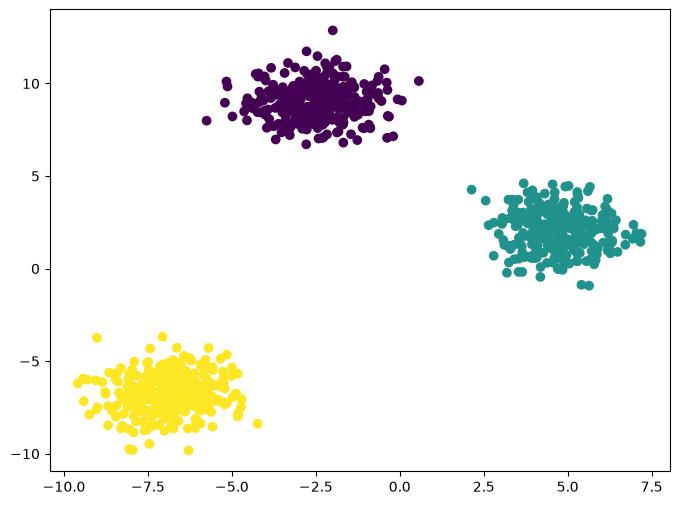

In [36]:
# Let's visualize dataset and see how it's clustered

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y)

In [37]:
# let's apply scaler and split our dataset

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Let's find out WCSS (Within-Cluster Sum of Squares, also called inertia) and see how K means uses Elbow method
# to find out optimal K value or number of clusters

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
    print(kmeans.inertia_)

1340.0
424.7795042841271
43.537817283488835
37.73172869596768
31.001209065632565
28.84849067110477
29.143743809221192
22.102230248306995
19.950483423474694
17.7059318167426


Text(0, 0.5, 'WCSS')

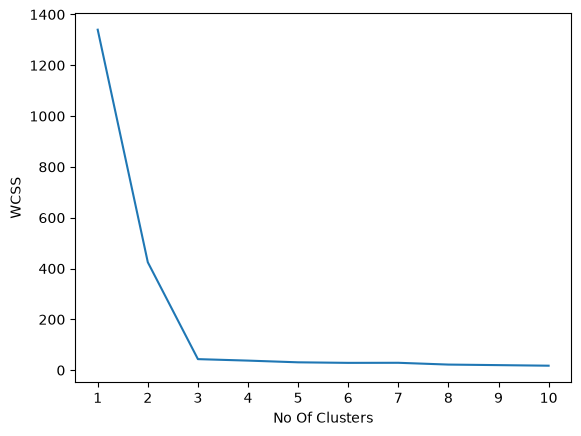

In [39]:
# let's plot wcss and see where the elbow forms and how algorithm determines number of clusters
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel('No Of Clusters')
plt.ylabel('WCSS')


In [40]:
# let's create our model with the optimal value of 3 and do predictions
kmeans = KMeans(n_clusters=3, init='k-means++')
kmeans.fit_predict(X_train_scaled)


array([0, 1, 0, 2, 1, 0, 0, 2, 0, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 0, 2,
       1, 2, 2, 0, 1, 2, 2, 1, 2, 1, 1, 1, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0,
       0, 2, 0, 0, 2, 1, 1, 2, 1, 0, 1, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 0, 1, 1, 0, 2, 2, 0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 2,
       2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 0, 2, 0, 2, 0, 1, 2, 2, 1, 1, 0,
       2, 1, 2, 1, 2, 1, 2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 0, 2, 0, 1, 0, 0,
       2, 0, 0, 1, 2, 2, 2, 1, 1, 0, 1, 2, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 0, 1, 0, 2, 1, 1, 2, 2, 1, 2,
       0, 0, 2, 0, 2, 0, 2, 1, 1, 1, 2, 0, 2, 2, 1, 1, 1, 0, 0, 2, 1, 0,
       1, 1, 0, 2, 1, 0, 0, 2, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 2, 1,
       1, 1, 0, 2, 1, 1, 2, 1, 0, 2, 2, 1, 2, 2, 0, 0, 1, 1, 2, 1, 2, 1,
       0, 2, 0, 0, 2, 0, 2, 1, 1, 0, 2, 1, 0, 0, 1, 0, 2, 1, 1, 2, 1, 2,
       1, 2, 1, 1, 1, 0, 1, 2, 2, 1, 1, 1, 1, 0, 2,

In [41]:
pred = kmeans.predict(X_test_scaled)

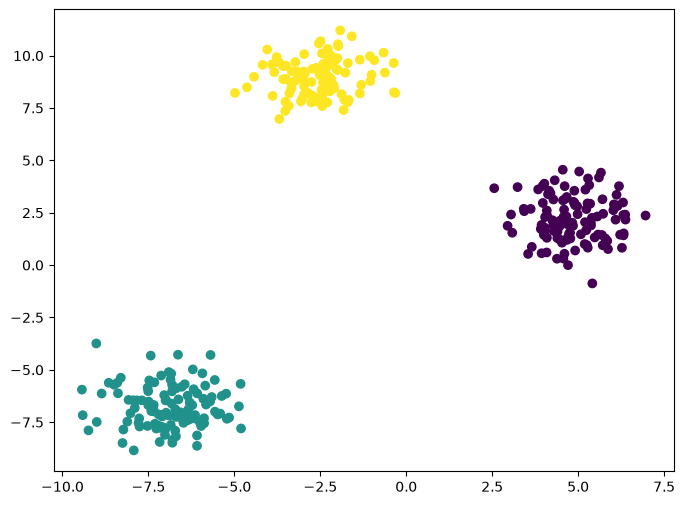

In [42]:
# Let's visualize how it clustered predictions 

plt.figure(figsize=(8,6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=pred)

In [43]:
# Let's see how we can validate k value using kneelocater and silhoutee scoring

kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
print(kl.elbow)

3


In [44]:
silhouette_coeff = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    silhouette_coeff.append(silhouette_score(X_train_scaled, kmeans.labels_))
print(silhouette_coeff)

[0.6857199772837788, 0.842476016737992, 0.6774649019945745, 0.5095867667301104, 0.49512118351580564, 0.49631783697184373, 0.32671138392550675, 0.34343047006856814, 0.3151168169011775]


Text(0, 0.5, 'silhouette Coeff')

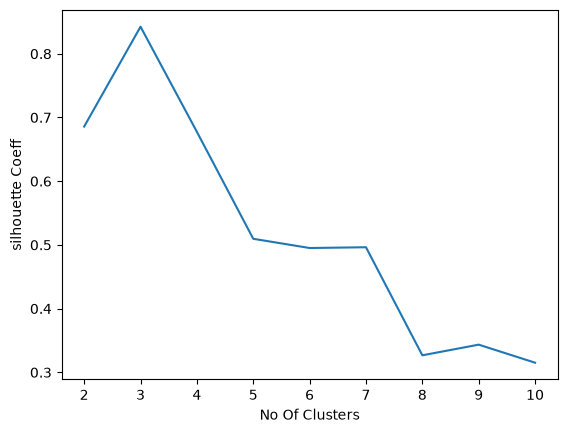

In [ ]:
# we can clearly see k value will be 3 which corresponds to the highest silhouette score
plt.plot(range(2, 11), silhouette_coeff)
plt.xticks(range(2, 11))
plt.xlabel('No Of Clusters')
plt.ylabel('silhouette Coeff')